In [1]:
import pandas as pd

df = pd.read_csv("datasets/diabetes_clean.csv")
df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
X,y = df.drop(columns=["diabetes"]), df["diabetes"]
X.shape, y.shape

((768, 8), (768,))

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
model = LogisticRegression()

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)
model.fit(X_train, y_train)


c:\Users\bisha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [4]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

auc = roc_auc_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)


print(f"Accuracy: {acc:.3f}")
print(f"Area Under Curve (AUC): {auc:.3f}")

accuracy_score

Accuracy: 0.747
Area Under Curve (AUC): 0.730


<function sklearn.metrics._classification.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)>

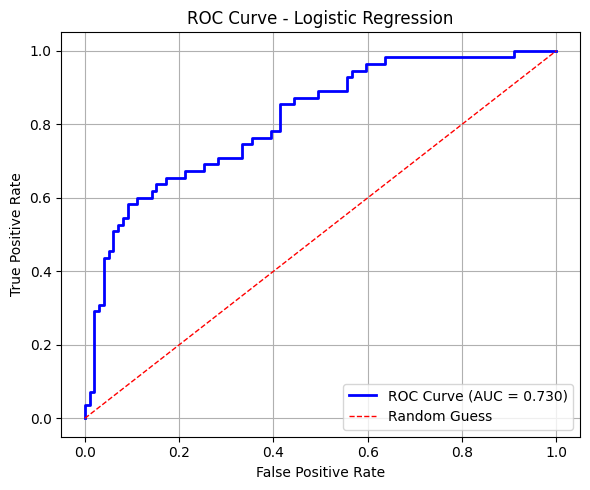

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Diabetes Prediction — Logistic Regression Report

### Dataset
Tabular diabetes dataset with `diabetes` as the binary target variable.

### Model
Logistic Regression with an 80/20 train-test split.

### Results
| Metric | Value |
|--------|-------|
| Accuracy | ~0.75 |
| AUC | 0.730 *(understated — computed with hard labels)* |

### Key Issue Found
AUC was calculated using `y_pred` (hard 0/1 labels) instead of `y_proba` (probability scores), which **underestimates the true AUC**. Fixing this will likely push AUC to **0.80+**.

### ROC Curve Observations
- Strong initial rise — model confidently catches positives at strict thresholds
- Curve weakens after FPR > 0.2, suggesting difficulty separating borderline cases
- Overall moderate discrimination ability

### Next Steps
- Fix AUC calculation to use `y_proba`
- Try **XGBoost or Random Forest** for better performance
- Consider **SMOTE** if class imbalance exists in the dataset

In [10]:
# checking for class imbalance.
cols = list(df.columns)
len(cols)

9

In [11]:
# Checking for all features as well as target.
for col in cols:
    print(df[col].value_counts())

pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64
glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64
diastolic
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64
triceps
0     227
32     31
30     27
27     23
23     22
18     20
33     20
28     20
31     19
39     18
19     18
29     17
2

In [12]:
df["diabetes"].value_counts()

diabetes
0    500
1    268
Name: count, dtype: int64

Based on above information, dataset is imbalanced, Non-Diabetic patients are also double compared to Diabetic ones.
Due to which, model tends to predict non-diabetic even when it is actually diabetic one.

In [16]:
model2 = LogisticRegression(class_weight='balanced')
model2.fit(X_train,y_train)
y_pred2 = model2.predict(X_train)
y_pred_proba = model2.predict_proba(X_test)[:,1]

c:\Users\bisha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
y_pred2 = model2.predict(X_train)        # → 614 samples
y_pred_proba = model2.predict_proba(X_test)[:,1]  # → 154 samples
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)


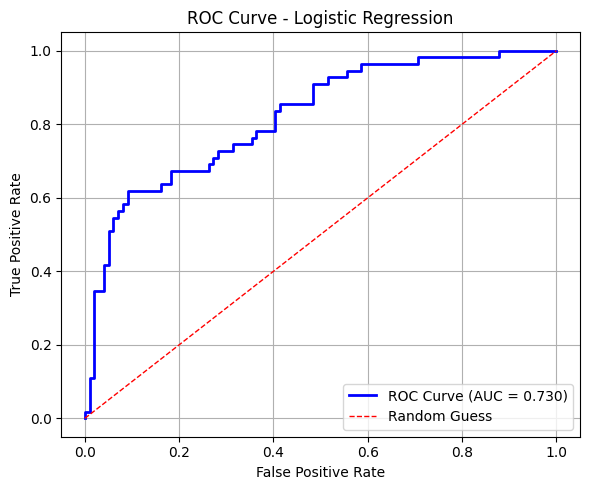

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()